In [66]:
import pandas as pd

df = pd.read_csv('adult_with_headers.csv')

In [67]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       32561 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education_num   32561 non-null  int64 
 5   marital_status  32561 non-null  object
 6   occupation      32561 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital_gain    32561 non-null  int64 
 11  capital_loss    32561 non-null  int64 
 12  hours_per_week  32561 non-null  int64 
 13  native_country  32561 non-null  object
 14  income          32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB


In [68]:
print(df.head())

   age          workclass  fnlwgt   education  education_num  \
0   39          State-gov   77516   Bachelors             13   
1   50   Self-emp-not-inc   83311   Bachelors             13   
2   38            Private  215646     HS-grad              9   
3   53            Private  234721        11th              7   
4   28            Private  338409   Bachelors             13   

        marital_status          occupation    relationship    race      sex  \
0        Never-married        Adm-clerical   Not-in-family   White     Male   
1   Married-civ-spouse     Exec-managerial         Husband   White     Male   
2             Divorced   Handlers-cleaners   Not-in-family   White     Male   
3   Married-civ-spouse   Handlers-cleaners         Husband   Black     Male   
4   Married-civ-spouse      Prof-specialty            Wife   Black   Female   

   capital_gain  capital_loss  hours_per_week  native_country  income  
0          2174             0              40   United-States   <=50

In [69]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       32561 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education_num   32561 non-null  int64 
 5   marital_status  32561 non-null  object
 6   occupation      32561 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital_gain    32561 non-null  int64 
 11  capital_loss    32561 non-null  int64 
 12  hours_per_week  32561 non-null  int64 
 13  native_country  32561 non-null  object
 14  income          32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB
None


In [70]:
print(df.describe())

                age        fnlwgt  education_num  capital_gain  capital_loss  \
count  32561.000000  3.256100e+04   32561.000000  32561.000000  32561.000000   
mean      38.581647  1.897784e+05      10.080679   1077.648844     87.303830   
std       13.640433  1.055500e+05       2.572720   7385.292085    402.960219   
min       17.000000  1.228500e+04       1.000000      0.000000      0.000000   
25%       28.000000  1.178270e+05       9.000000      0.000000      0.000000   
50%       37.000000  1.783560e+05      10.000000      0.000000      0.000000   
75%       48.000000  2.370510e+05      12.000000      0.000000      0.000000   
max       90.000000  1.484705e+06      16.000000  99999.000000   4356.000000   

       hours_per_week  
count    32561.000000  
mean        40.437456  
std         12.347429  
min          1.000000  
25%         40.000000  
50%         40.000000  
75%         45.000000  
max         99.000000  


In [71]:
print(df.isnull().sum())

age               0
workclass         0
fnlwgt            0
education         0
education_num     0
marital_status    0
occupation        0
relationship      0
race              0
sex               0
capital_gain      0
capital_loss      0
hours_per_week    0
native_country    0
income            0
dtype: int64


In [72]:
print(df.isnull().sum())

age               0
workclass         0
fnlwgt            0
education         0
education_num     0
marital_status    0
occupation        0
relationship      0
race              0
sex               0
capital_gain      0
capital_loss      0
hours_per_week    0
native_country    0
income            0
dtype: int64


In [80]:
from sklearn.impute import KNNImputer

In [83]:
import pandas as pd
from sklearn.impute import KNNImputer

# Load the dataset
df = pd.read_csv('adult_with_headers.csv')

# Check for missing values
print(df.isnull().sum())

# Separate numeric and categorical columns
numeric_columns = df.select_dtypes(include=['float64', 'int64']).columns
categorical_columns = df.select_dtypes(include=['object']).columns

# Impute numeric columns with the median
for column in numeric_columns:
    df[column] = df[column].fillna(df[column].median())

# Impute categorical columns with the mode (most frequent value)
for column in categorical_columns:
    df[column] = df[column].fillna(df[column].mode()[0])
# Now, apply KNN imputation to numeric columns only
imputer = KNNImputer(n_neighbors=5)

# Only apply KNN to the numeric columns
df_numeric_imputed = pd.DataFrame(imputer.fit_transform(df[numeric_columns]), columns=numeric_columns)

# Replace the imputed numeric columns back into the original dataframe
df[numeric_columns] = df_numeric_imputed

# Check for missing values again after imputation
print(df.isnull().sum())

age               0
workclass         0
fnlwgt            0
education         0
education_num     0
marital_status    0
occupation        0
relationship      0
race              0
sex               0
capital_gain      0
capital_loss      0
hours_per_week    0
native_country    0
income            0
dtype: int64
age               0
workclass         0
fnlwgt            0
education         0
education_num     0
marital_status    0
occupation        0
relationship      0
race              0
sex               0
capital_gain      0
capital_loss      0
hours_per_week    0
native_country    0
income            0
dtype: int64


In [84]:
import pandas as pd
from sklearn.preprocessing import StandardScaler, MinMaxScaler

# Load the dataset
df = pd.read_csv('adult_with_headers.csv')

# Separate numeric columns
numeric_columns = df.select_dtypes(include=['float64', 'int64']).columns

# Apply Standard Scaling (z-score normalization)
scaler_standard = StandardScaler()
df_standard_scaled = df.copy()
df_standard_scaled[numeric_columns] = scaler_standard.fit_transform(df[numeric_columns])

# Apply Min-Max Scaling
scaler_minmax = MinMaxScaler()
df_minmax_scaled = df.copy()
df_minmax_scaled[numeric_columns] = scaler_minmax.fit_transform(df[numeric_columns])

# Display the scaled data
print("Standard Scaled Data:")
print(df_standard_scaled.head())

print("\nMin-Max Scaled Data:")
print(df_minmax_scaled.head())

Standard Scaled Data:
        age          workclass    fnlwgt   education  education_num  \
0  0.030671          State-gov -1.063611   Bachelors       1.134739   
1  0.837109   Self-emp-not-inc -1.008707   Bachelors       1.134739   
2 -0.042642            Private  0.245079     HS-grad      -0.420060   
3  1.057047            Private  0.425801        11th      -1.197459   
4 -0.775768            Private  1.408176   Bachelors       1.134739   

        marital_status          occupation    relationship    race      sex  \
0        Never-married        Adm-clerical   Not-in-family   White     Male   
1   Married-civ-spouse     Exec-managerial         Husband   White     Male   
2             Divorced   Handlers-cleaners   Not-in-family   White     Male   
3   Married-civ-spouse   Handlers-cleaners         Husband   Black     Male   
4   Married-civ-spouse      Prof-specialty            Wife   Black   Female   

   capital_gain  capital_loss  hours_per_week  native_country  income  
0   

In [101]:
import pandas as pd

# Sample dataset (assuming df is your DataFrame)
df = pd.DataFrame({
    'age': [23, 25, 30, 35, 40],
    'gender': ['Male', 'Female', 'Female', 'Male', 'Female'],
    'education': ['Bachelor', 'Master', 'PhD', 'Master', 'Bachelor'],
    'region': ['North', 'South', 'East', 'West', 'North'],
})

# Step 1: Identify categorical columns
categorical_columns = df.select_dtypes(include=['object']).columns

# Step 2: Filter columns with fewer than 5 categories
low_cardinality_columns = [col for col in categorical_columns if df[col].nunique() < 5]

# Step 3: Apply One-Hot Encoding to those columns
df_encoded = pd.get_dummies(df, columns=low_cardinality_columns, drop_first=True)

# Display the encoded DataFrame
print(df_encoded)

   age  gender_Male  education_Master  education_PhD  region_North  \
0   23         True             False          False          True   
1   25        False              True          False         False   
2   30        False             False           True         False   
3   35         True              True          False         False   
4   40        False             False          False          True   

   region_South  region_West  
0         False        False  
1          True        False  
2         False        False  
3         False         True  
4         False        False  


In [104]:
from sklearn.preprocessing import LabelEncoder
import pandas as pd

# Sample dataset
df = pd.DataFrame({
    'product': ['Laptop', 'Tablet', 'Smartphone', 'Smartwatch', 'Desktop', 'Tablet', 'Smartphone'],
    'category': ['Electronics', 'Electronics', 'Electronics', 'Wearable', 'Electronics', 'Electronics', 'Electronics'],
    'color': ['Red', 'Blue', 'Black', 'Green', 'Black', 'Red', 'Blue']
})

# Step 1: Identify categorical columns
categorical_columns = df.select_dtypes(include=['object']).columns

# Step 2: Filter columns with more than 5 unique categories
high_cardinality_columns = [col for col in categorical_columns if df[col].nunique() > 5]

# Step 3: Apply Label Encoding to those columns
label_encoders = {}  # Dictionary to store label encoders for each column
for col in high_cardinality_columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le  # Store the encoder for future inverse transformations

# Display the updated DataFrame
print(df)

# Optional: Decode (inverse transform) an example encoded column for demonstration
if 'product' in label_encoders:
    print(label_encoders['product'].inverse_transform(df['product']))

      product     category  color
0      Laptop  Electronics    Red
1      Tablet  Electronics   Blue
2  Smartphone  Electronics  Black
3  Smartwatch     Wearable  Green
4     Desktop  Electronics  Black
5      Tablet  Electronics    Red
6  Smartphone  Electronics   Blue


In [105]:
print(df.columns)

Index(['product', 'category', 'color'], dtype='object')


In [88]:
print('age' in df.columns)

False


In [89]:
print(df.columns)

Index(['product', 'category', 'color'], dtype='object')


In [90]:
df['Product_Length'] = df['product'].apply(len)

In [91]:
df['Category_Color'] = df['category'] + '_' + df['color']

In [92]:
import numpy as np

# Simulate a numerical column with a skewed distribution
df['sales'] = np.random.exponential(scale=10, size=len(df))

In [93]:
from scipy.stats import skew

# Calculate skewness
print("Skewness of sales:", skew(df['sales']))

Skewness of sales: 0.14736976108762728


In [94]:
# Apply log transformation
df['sales_log'] = np.log1p(df['sales'])  # Using log1p to handle zero values safely
# Recalculate skewness
print("Skewness after log transformation:", skew(df['sales_log']))

Skewness after log transformation: -1.2919141741716829


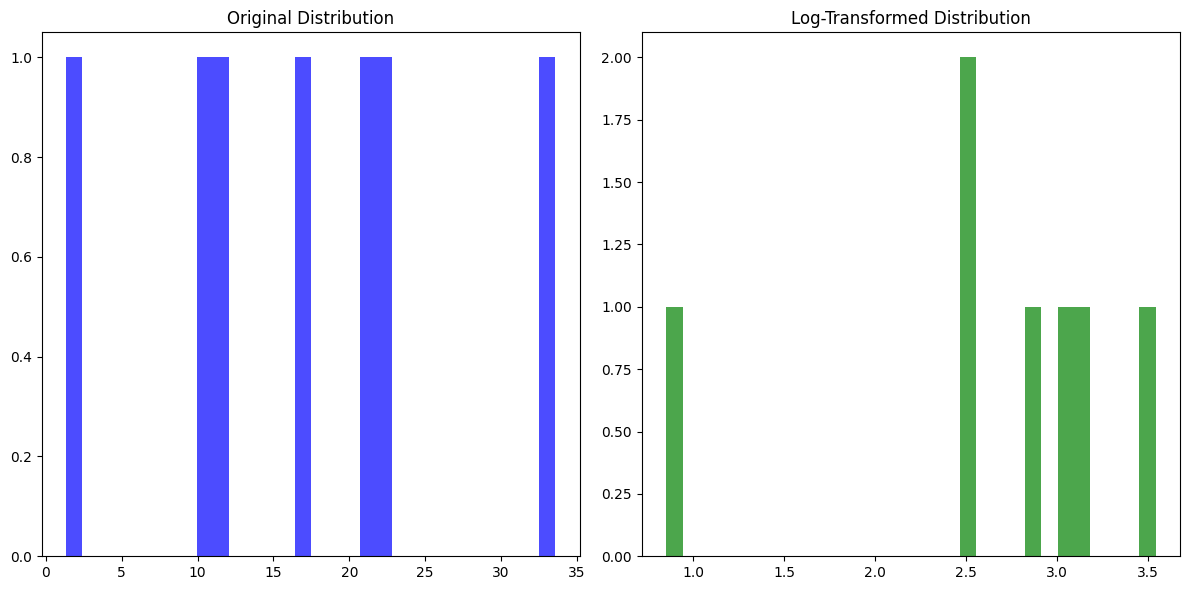

In [95]:
import matplotlib.pyplot as plt

# Plot original vs transformed distribution
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.hist(df['sales'], bins=30, color='blue', alpha=0.7)
plt.title("Original Distribution")

plt.subplot(1, 2, 2)
plt.hist(df['sales_log'], bins=30, color='green', alpha=0.7)
plt.title("Log-Transformed Distribution")

plt.tight_layout()
plt.show()

In [102]:
df

,age,gender,education,region
0,23,Male,Bachelor,North
1,25,Female,Master,South
2,30,Female,PhD,East
3,35,Male,Master,West
4,40,Female,Bachelor,North


In [106]:
df = pd.get_dummies(df, columns=['product'],drop_first=True)


In [107]:
df = pd.get_dummies(df, columns=['category'],drop_first=True)

In [108]:
df = pd.get_dummies(df, columns=['color'],drop_first=True)

In [114]:
df = df.astype(int)
df

,product_Laptop,product_Smartphone,product_Smartwatch,product_Tablet,category_Wearable,color_Blue,color_Green,color_Red
0,1,0,0,0,0,0,0,1
1,0,0,0,1,0,1,0,0
2,0,1,0,0,0,0,0,0
3,0,0,1,0,1,0,1,0
4,0,0,0,0,0,0,0,0
5,0,0,0,1,0,0,0,1
6,0,1,0,0,0,1,0,0


In [115]:
df.corr()

,product_Laptop,product_Smartphone,product_Smartwatch,product_Tablet,category_Wearable,color_Blue,color_Green,color_Red
product_Laptop,1.000000,-0.258199,-0.166667,-0.258199,-0.166667,-0.258199,-0.166667,0.645497
product_Smartphone,-0.258199,1.000000,-0.258199,-0.400000,-0.258199,0.300000,-0.258199,-0.400000
product_Smartwatch,-0.166667,-0.258199,1.000000,-0.258199,1.000000,-0.258199,1.000000,-0.258199
product_Tablet,-0.258199,-0.400000,-0.258199,1.000000,-0.258199,0.300000,-0.258199,0.300000
category_Wearable,-0.166667,-0.258199,1.000000,-0.258199,1.000000,-0.258199,1.000000,-0.258199
color_Blue,-0.258199,0.300000,-0.258199,0.300000,-0.258199,1.000000,-0.258199,-0.400000
color_Green,-0.166667,-0.258199,1.000000,-0.258199,1.000000,-0.258199,1.000000,-0.258199
color_Red,0.645497,-0.400000,-0.258199,0.300000,-0.258199,-0.400000,-0.258199,1.000000


In [61]:
df

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,39.0,State-gov,77516.0,Bachelors,13.0,Never-married,Adm-clerical,Not-in-family,White,Male,2174.0,0.0,40.0,United-States,<=50K
1,50.0,Self-emp-not-inc,83311.0,Bachelors,13.0,Married-civ-spouse,Exec-managerial,Husband,White,Male,0.0,0.0,13.0,United-States,<=50K
2,38.0,Private,215646.0,HS-grad,9.0,Divorced,Handlers-cleaners,Not-in-family,White,Male,0.0,0.0,40.0,United-States,<=50K
3,53.0,Private,234721.0,11th,7.0,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0.0,0.0,40.0,United-States,<=50K
4,28.0,Private,338409.0,Bachelors,13.0,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0.0,0.0,40.0,Cuba,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32556,27.0,Private,257302.0,Assoc-acdm,12.0,Married-civ-spouse,Tech-support,Wife,White,Female,0.0,0.0,38.0,United-States,<=50K
32557,40.0,Private,154374.0,HS-grad,9.0,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0.0,0.0,40.0,United-States,>50K
32558,58.0,Private,151910.0,HS-grad,9.0,Widowed,Adm-clerical,Unmarried,White,Female,0.0,0.0,40.0,United-States,<=50K
32559,22.0,Private,201490.0,HS-grad,9.0,Never-married,Adm-clerical,Own-child,White,Male,0.0,0.0,20.0,United-States,<=50K


In [33]:
from sklearn.ensemble import IsolationForest
import pandas as pd

# Assuming `df` is your DataFrame
# Initialize the Isolation Forest model
iso_forest = IsolationForest(contamination=0.05, random_state=42)  # Adjust contamination based on expected outliers

# Fit the model on the dataset (numeric columns only)
numeric_columns = df.select_dtypes(include=['float64', 'int64']).columns
iso_forest.fit(df[numeric_columns])

# Predict outliers (-1 for outliers, 1 for inliers)
df['outlier'] = iso_forest.predict(df[numeric_columns])

# Filter to retain only inliers
df_cleaned = df[df['outlier'] == 1].drop(columns=['outlier'])

print(f"Number of rows before removing outliers: {df.shape[0]}")
print(f"Number of rows after removing outliers: {df_cleaned.shape[0]}")

Number of rows before removing outliers: 7
Number of rows after removing outliers: 6


In [116]:
df.corr()

,product_Laptop,product_Smartphone,product_Smartwatch,product_Tablet,category_Wearable,color_Blue,color_Green,color_Red
product_Laptop,1.000000,-0.258199,-0.166667,-0.258199,-0.166667,-0.258199,-0.166667,0.645497
product_Smartphone,-0.258199,1.000000,-0.258199,-0.400000,-0.258199,0.300000,-0.258199,-0.400000
product_Smartwatch,-0.166667,-0.258199,1.000000,-0.258199,1.000000,-0.258199,1.000000,-0.258199
product_Tablet,-0.258199,-0.400000,-0.258199,1.000000,-0.258199,0.300000,-0.258199,0.300000
category_Wearable,-0.166667,-0.258199,1.000000,-0.258199,1.000000,-0.258199,1.000000,-0.258199
color_Blue,-0.258199,0.300000,-0.258199,0.300000,-0.258199,1.000000,-0.258199,-0.400000
color_Green,-0.166667,-0.258199,1.000000,-0.258199,1.000000,-0.258199,1.000000,-0.258199
color_Red,0.645497,-0.400000,-0.258199,0.300000,-0.258199,-0.400000,-0.258199,1.000000


In [117]:
import pandas as pd

# Sample dataset
data = {
    'Age': [25, 30, 35, 40, 45],
    'Salary': [50000, 60000, 70000, 80000, 90000],
    'Education_Level': [1, 2, 2, 3, 3],
    'Years_Experience': [1, 3, 5, 7, 10]
}

df = pd.DataFrame(data)

In [118]:
# Correlation matrix
correlation_matrix = df.corr()
print("Correlation Matrix:")
print(correlation_matrix)

Correlation Matrix:
                       Age    Salary  Education_Level  Years_Experience
Age               1.000000  1.000000         0.944911          0.995893
Salary            1.000000  1.000000         0.944911          0.995893
Education_Level   0.944911  0.944911         1.000000          0.923921
Years_Experience  0.995893  0.995893         0.923921          1.000000


In [122]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

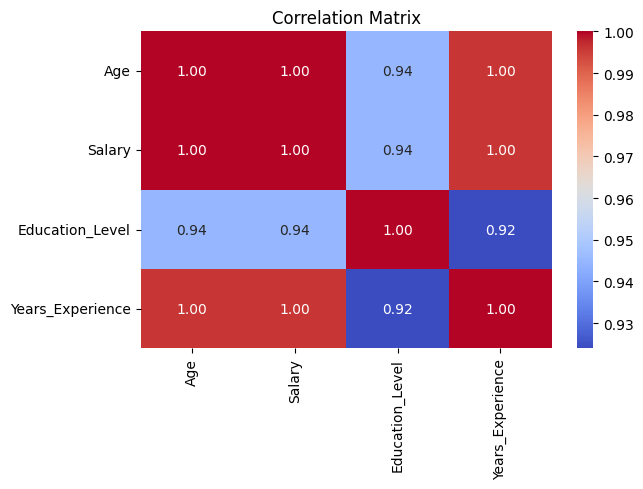

In [123]:
# Plot the Correlation Matrix
plt.figure(figsize=(12, 5))

# Correlation heatmap
plt.subplot(1, 2, 1)
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", cbar=True)
plt.title('Correlation Matrix')


# Display the plots
plt.tight_layout()
plt.show()